# Uptake Comparison Across Tools

This notebook compares the attached uptake-by-cells outputs from BioDynaMo, Chaste, CompuTiX, PhysiCell, and TiSim against the analytical solution using native timestamps only.

The workflow is split into the same broad steps as the decay comparison notebook:
1. Load the result files into one common table using both the whole-box average concentration and the center concentration.
2. Load the analytical reference table.
3. Match each native simulation timepoint to the identical analytical timepoint; no rounding, interpolation, nearest-time tolerance, or duplicate aggregation is used.
4. Compute the relative error and the absolute error for every matched run and rank the runs within each tool.
5. Plot the missing concentration time courses as well as the error summaries for the selected runs.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


## Step 1: Define Study Paths And Shared Physical Parameters

The five tools store their outputs in different formats, but they represent the same uptake-by-cells comparison.
For BioDynaMo, the source timestamps are seconds and are converted to minutes without rounding. Every other loader also preserves its native time values.

In [2]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')

BIODYNAMO_DIR = ROOT / 'Biodynamo' / 'diffusion_uptake_test'
CHASTE_DIR = ROOT / 'Chaste' / 'DiffusionWithCells'
COMPUTIX_DIR = ROOT / 'CompuTiX' / 'diffusion_single' / 'CellsAtCenter'
PHYSICELL_DIR = ROOT / 'PhysiCell' / 'results' / 'decay_study' 
PHYSICELL_EXPORT_FILENAME = 'physicell_uptake_plot_data.csv'
ANALYTICAL_DIR = ROOT / 'analytical_solutions' / 'diffusion' / 'Cellsatcenter'
ANALYTICAL_PARAMETERS = {
    'box_length_um': 240.0,
    'initial_concentration_uM': 10.0,
}


## Step 2: Load The Analytical Reference Table

The analytical reference comes from the uptake analytical CSV.

Both the whole-box average concentration and the center concentration are loaded so we can compute relative and absolute error for the same two metrics used in the decay notebook.

In [3]:
analytical_df = pd.read_csv(
    ANALYTICAL_DIR / 'analytical_values.csv',
    usecols=['time_min', 'center_concentration_uM', 'average_concentration_uM'],
    dtype={
        'time_min': float,
        'center_concentration_uM': float,
        'average_concentration_uM': float,
    },
)
analytical_df['time_min'] = analytical_df['time_min'].round(4)

analytical_df

,time_min,center_concentration_uM,average_concentration_uM
0,0.0000,10.000000,10.000000
1,0.0001,9.995468,9.999986
2,0.0002,9.992037,9.999972
3,0.0003,9.989457,9.999959
4,0.0004,9.987532,9.999945
...,...,...,...
99996,9.9996,7.127679,9.783748
99997,9.9997,7.127679,9.783748
99998,9.9998,7.127679,9.783748
99999,9.9999,7.127679,9.783748


## Step 3: Load Every Attached Result Into One Common Table

Each loader returns a table with the same columns: tool name, run identifier, time in minutes, spatial resolution in um, whole-box average concentration in uM, and the concentration used for the center comparison metric.

BioDynaMo uses columns 2 and 3 from the text file and converts column 1 from seconds to minutes. Chaste, CompuTiX, PhysiCell, and TiSim preserve their native timestamps. The later comparison joins these values to the analytical table on exact `time_min` equality.

In [4]:
def format_resolution_label(tool: str, dx_um: float, n_voxels_per_dim: int | None = None, dt_min: float | None = None) -> str:
    if tool in {'BioDynaMo', 'Chaste'}:
        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.0f} um'

    if tool == 'CompuTiX':
        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.2f} um, dt={dt_min:.1e} min'

    if tool == 'PhysiCell':
        return f'voxel size={dx_um:.0f} um'

    if tool == 'TiSim':
        return f'N={n_voxels_per_dim} bins, dx={dx_um:.0f} um'

    return f'dx={dx_um:.0f} um'


def load_biodynamo_runs() -> list[pd.DataFrame]:
    runs = []
    for csv_path in sorted(BIODYNAMO_DIR.glob('data_*.csv')):
        n_voxels_per_dim = int(csv_path.stem.split('_')[1])
        dx_um = ANALYTICAL_PARAMETERS['box_length_um'] / n_voxels_per_dim
        frame = pd.read_csv(csv_path, sep=r'\s+', header=None, names=['time_s', 'average_uM', 'center_uM'])
        frame['time_min'] = frame['time_s'] 
        run_id = f'BioDynaMo_N_{n_voxels_per_dim}'
        frame = frame.assign(
            tool='BioDynaMo',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='text file column 2: average_uM',
            center_source='text file column 3: center_uM',
            resolution_label=format_resolution_label('BioDynaMo', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),
        )
        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']])
    return runs


def load_chaste_runs() -> list[pd.DataFrame]:
    runs = []
    for txt_path in sorted(CHASTE_DIR.glob('*.txt')):
        n_voxels_per_dim = int(txt_path.stem)
        dx_um = ANALYTICAL_PARAMETERS['box_length_um'] / n_voxels_per_dim
        frame = pd.read_csv(txt_path, sep=r'\s+', header=None, names=['time_min', 'center_uM', 'average_uM'])
        run_id = f'Chaste_N_{n_voxels_per_dim}'
        frame = frame.assign(
            tool='Chaste',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='txt column 3: average_uM',
            center_source='txt column 2: center_uM',
            resolution_label=format_resolution_label('Chaste', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),
        )
        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']])
    return runs


def load_computix_runs() -> list[pd.DataFrame]:
    runs = []
    for yaml_path in sorted(COMPUTIX_DIR.glob('dt-s-006_N-*.yaml')):
        data = yaml.safe_load(yaml_path.read_text())
        dx_um = float(data['dx']['values']) * 1e6
        dt_min = float(data['dt']['values']) 
        n_voxels_per_dim = int(data['N']['values'])
        frame = pd.DataFrame({
            'time_min': np.array(data['time_series']['values']['t']['values'], dtype=float) / 60.0,
            'average_uM': 1e3 * np.array(data['time_series']['values']['c_domain']['values'], dtype=float),
            'center_uM': 1e3 * np.array(data['time_series']['values']['c_central']['values'], dtype=float),
        })
        run_id = f'CompuTiX_N_{n_voxels_per_dim}_dt_{dt_min:.5g}min'
        # frame['time_min'] = frame['time_min'] * 60.0 #second to minutes

        frame = frame.assign(
            tool='CompuTiX',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=dt_min,
            average_source='YAML time_series.values.c_domain.values',
            center_source='YAML time_series.values.c_central.values',
            resolution_label=format_resolution_label('CompuTiX', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim, dt_min=dt_min),
        )
        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']])
    return runs


def load_physicell_runs() -> list[pd.DataFrame]:
    # Only look in the uptake run folders, not the sibling decay-only size_* folders.
    csv_paths = sorted(PHYSICELL_DIR.glob(f'size_*_uptake/{PHYSICELL_EXPORT_FILENAME}'))

    if not csv_paths:
        raise FileNotFoundError(
            f'No PhysiCell export CSVs found in {PHYSICELL_DIR}. Run the PhysiCell uptake export first.'
        )

    runs = []
    for csv_path in csv_paths:
        frame = pd.read_csv(csv_path)

        if 'time_min' not in frame.columns or 'average_uM' not in frame.columns:
            raise ValueError(f'{csv_path} must contain at least time_min and average_uM columns.')

        if 'origin_center_uM' in frame.columns:
            center_values = frame['origin_center_uM']
            center_source = 'CSV origin_center_uM (trilinear interpolation at origin)'
        elif 'center_uM' in frame.columns and 'center_source' in frame.columns:
            center_values = frame['center_uM']
            center_source = frame['center_source'].iloc[0]
        elif 'center_uM' in frame.columns:
            center_values = frame['center_uM']
            center_source = 'CSV center_uM'
        elif 'cell_voxel_average_uM' in frame.columns:
            center_values = frame['cell_voxel_average_uM']
            center_source = 'CSV cell_voxel_average_uM (average over occupied cell voxels)'
        else:
            raise ValueError(
                f'{csv_path} is missing a center concentration column. Expected one of '
                "['origin_center_uM', 'center_uM', 'cell_voxel_average_uM']."
            )

        tool_value = frame['tool'].iloc[0] if 'tool' in frame.columns else 'PhysiCell'
        run_id_value = frame['run_id'].iloc[0] if 'run_id' in frame.columns else csv_path.parent.name
        dx_value = float(frame['dx_um'].iloc[0]) if 'dx_um' in frame.columns else np.nan

        if 'dt_min' in frame.columns:
            dt_value = frame['dt_min'].iloc[0]
        elif 'dt_diffusion_min' in frame.columns:
            dt_value = frame['dt_diffusion_min'].iloc[0]
        else:
            dt_value = np.nan

        average_source = frame['average_source'].iloc[0] if 'average_source' in frame.columns else 'CSV average_uM'

        if 'resolution_label' in frame.columns:
            resolution_label = frame['resolution_label'].iloc[0]
        elif np.isfinite(dx_value):
            resolution_label = format_resolution_label('PhysiCell', dx_um=dx_value)
        else:
            resolution_label = f'run={run_id_value}'

        standardized = pd.DataFrame({
            'tool': tool_value,
            'run_id': run_id_value,
            'dx_um': dx_value,
            'dt_min': dt_value,
            'average_source': average_source,
            'center_source': center_source,
            'resolution_label': resolution_label,
            'time_min': frame['time_min'],
            'average_uM': frame['average_uM'],
            'center_uM': center_values,
        })

        runs.append(standardized)

    return runs


def load_tisim_runs() -> list[pd.DataFrame]:
    tisim_dir = ROOT / 'Tisim' / 'diffusion_uptake_test'
    runs = []

    for csv_path in sorted(tisim_dir.glob('data_*.csv')):
        n_bins = int(csv_path.stem.split('_')[1])
        dx_um = ANALYTICAL_PARAMETERS['box_length_um'] / n_bins
        frame = pd.read_csv(csv_path)
        run_id = f'TiSim_N_{n_bins}'
        frame = frame.assign(
            tool='TiSim',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='CSV average_uM',
            center_source='CSV center_uM',
            resolution_label=format_resolution_label('TiSim', dx_um=dx_um, n_voxels_per_dim=n_bins),
        )
        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']])
    return runs


all_runs = pd.concat(
    load_biodynamo_runs() + load_chaste_runs() + load_computix_runs() + load_physicell_runs() + load_tisim_runs(),
    ignore_index=True,
)

assert not all_runs['average_uM'].isna().any()
assert not all_runs['center_uM'].isna().any()
assert np.isfinite(all_runs['time_min']).all()
assert not all_runs.duplicated(['tool', 'run_id', 'time_min']).any()

run_catalog = (
    all_runs[
        ['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label']
    ]
    .drop_duplicates()
    .sort_values(['tool', 'dx_um', 'dt_min'])
)

tool_colors = {
    'BioDynaMo': '#ff7f00',
    'Chaste': '#377eb8',
    'CompuTiX': '#fd2a2a',
    'PhysiCell': '#4daf4a',
    'TiSim': '#984ea3',
}

metric_titles = {
    'average': 'Whole-box average concentration',
    'center': 'Center concentration',
}

metric_file_tokens = {
    'average': 'whole_box_average',
    'center': 'center_concentration',
}

plot_output_dir = ROOT / 'ResultAnalysis' / 'uptake_tools_comparison_plots'
plot_output_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 160,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


def style_axis(axis) -> None:
    axis.set_facecolor('#fbfbfc')
    axis.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.35)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_color('#4a4a4a')
    axis.spines['bottom'].set_color('#4a4a4a')


def save_and_show(fig, filename: str) -> None:
    fig.savefig(plot_output_dir / filename, bbox_inches='tight', dpi=300, facecolor='white')
    plt.show()
    plt.close(fig)


run_catalog

,tool,run_id,dx_um,dt_min,average_source,center_source,resolution_label
11000,BioDynaMo,BioDynaMo_N_48,5.0,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=48 voxels/dim, dx=5 um"
1000,BioDynaMo,BioDynaMo_N_24,10.0,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=24 voxels/dim, dx=10 um"
0,BioDynaMo,BioDynaMo_N_12,20.0,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=12 voxels/dim, dx=20 um"
21000,BioDynaMo,BioDynaMo_N_6,40.0,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=6 voxels/dim, dx=40 um"
22202,Chaste,Chaste_N_48,5.0,NaN,txt column 3: average_uM,txt column 2: center_uM,"N=48 voxels/dim, dx=5 um"
22101,Chaste,Chaste_N_24,10.0,NaN,txt column 3: average_uM,txt column 2: center_uM,"N=24 voxels/dim, dx=10 um"
22000,Chaste,Chaste_N_12,20.0,NaN,txt column 3: average_uM,txt column 2: center_uM,"N=12 voxels/dim, dx=20 um"
22303,Chaste,Chaste_N_6,40.0,NaN,txt column 3: average_uM,txt column 2: center_uM,"N=6 voxels/dim, dx=40 um"
25407,PhysiCell,PhysiCell_dx_5um_uptake,5.0,NaN,mean over all voxels,single center voxel nearest the origin,voxel size=5 um
22404,PhysiCell,PhysiCell_dx_10um_uptake,10.0,NaN,mean over all voxels,single center voxel nearest the origin,voxel size=10 um


In [5]:
plot_output_dir = ROOT / 'SuppMat' / 'SuppMatPlots' / 'diffusion_uptake_comparison'
plot_output_dir.mkdir(parents=True, exist_ok=True)

## Step 4: Match Rounded Analytical Time Points And Aggregate Duplicate Matches

The analytical CSV is matched on the same rounded time grid used by the tool outputs.

Each run is first matched only on time points that are present in both the run output and the analytical table. After the relative error and absolute error are computed, duplicate matches at the same time point are aggregated to one value per tool, run, metric, and time. This removes the rounded-time duplication artifact while keeping the common-time comparison approach.

In [6]:
analytical_reference = analytical_df.rename(
    columns={
        'center_concentration_uM': 'analytical_center_uM',
        'average_concentration_uM': 'analytical_average_uM',
    }
).copy()

assert not analytical_reference['time_min'].duplicated().any()
assert not all_runs.duplicated(['tool', 'run_id', 'time_min']).any()

# Match native tool timestamps to identical analytical timestamps only.
# No rounding, nearest-neighbor matching, interpolation, or duplicate aggregation is applied.
comparison = all_runs.merge(
    analytical_reference,
    on='time_min',
    how='inner',
    validate='many_to_one',
)

comparison_average = comparison.assign(
    metric='average',
    simulated_uM=comparison['average_uM'],
    analytical_uM=comparison['analytical_average_uM'],
    source_column=comparison['average_source'],
)

comparison_center = comparison.assign(
    metric='center',
    simulated_uM=comparison['center_uM'],
    analytical_uM=comparison['analytical_center_uM'],
    source_column=comparison['center_source'],
)

comparison = pd.concat([comparison_average, comparison_center], ignore_index=True)

comparison['relative_error_percent'] = (
    100.0
    * (comparison['simulated_uM'] - comparison['analytical_uM']).abs()
    / comparison['analytical_uM'].abs()
)
comparison['absolute_error_uM'] = (comparison['simulated_uM'] - comparison['analytical_uM']).abs()

comparison_counts = comparison.groupby(['metric', 'tool', 'run_id']).size()
assert (comparison_counts > 0).all()

relative_run_metrics = (
    comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_relative_error_percent=('relative_error_percent', 'mean'),
        max_relative_error_percent=('relative_error_percent', 'max'),
        rmse_percent=('relative_error_percent', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
)

absolute_run_metrics = (
    comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_absolute_error_uM=('absolute_error_uM', 'mean'),
        max_absolute_error_uM=('absolute_error_uM', 'max'),
        rmse_uM=('absolute_error_uM', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
)

print('Exact matched samples by tool and metric:')
print(comparison.groupby(['metric', 'tool'])['time_min'].size())
relative_run_metrics

Exact matched samples by tool and metric:
metric   tool     
average  BioDynaMo    22000
         Chaste         404
         PhysiCell     4004
         TiSim          303
center   BioDynaMo    22000
         Chaste         404
         PhysiCell     4004
         TiSim          303
Name: time_min, dtype: int64


,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_relative_error_percent,max_relative_error_percent,rmse_percent
2,average,BioDynaMo,BioDynaMo_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",10000,0.077461,0.098452,0.083419
1,average,BioDynaMo,BioDynaMo_N_24,10.0,NaN,"N=24 voxels/dim, dx=10 um",10000,0.160839,0.202208,0.172553
0,average,BioDynaMo,BioDynaMo_N_12,20.0,NaN,"N=12 voxels/dim, dx=20 um",1000,0.322707,0.401095,0.344984
3,average,BioDynaMo,BioDynaMo_N_6,40.0,NaN,"N=6 voxels/dim, dx=40 um",1000,0.693706,0.835591,0.733286
6,average,Chaste,Chaste_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",101,0.128786,0.151603,0.133259
5,average,Chaste,Chaste_N_24,10.0,NaN,"N=24 voxels/dim, dx=10 um",101,0.245257,0.282999,0.253810
4,average,Chaste,Chaste_N_12,20.0,NaN,"N=12 voxels/dim, dx=20 um",101,0.454179,0.523081,0.470471
7,average,Chaste,Chaste_N_6,40.0,NaN,"N=6 voxels/dim, dx=40 um",101,0.832645,0.962626,0.864568
11,average,PhysiCell,PhysiCell_dx_5um_uptake,5.0,NaN,voxel size=5 um,1001,0.038289,0.050579,0.041893
8,average,PhysiCell,PhysiCell_dx_10um_uptake,10.0,NaN,voxel size=10 um,1001,0.102038,0.127684,0.109192


## Step 5: Keep Only The Best Resolution Per Tool And Per Metric

Now we select the run with the smallest mean relative error inside each tool family, separately for the whole-box average and for the center concentration.

This shows which resolution is closest to the analytical solution for each tool under each comparison metric.

In [7]:
# Select the best run per tool using the whole-box average metric only, then reuse that
# same run_id to report the corresponding center-metric results.
best_run_ids_by_relative_error = (
    relative_run_metrics[relative_run_metrics['metric'] == 'average']
    .sort_values(['tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
    .groupby('tool', as_index=False)
    .first()[['tool', 'run_id']]
)

relative_best_runs = (
    relative_run_metrics.merge(best_run_ids_by_relative_error, on=['tool', 'run_id'], how='inner')
    .sort_values(['metric', 'mean_relative_error_percent'])
)

relative_best_runs

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_relative_error_percent,max_relative_error_percent,rmse_percent
2,average,PhysiCell,PhysiCell_dx_5um_uptake,5.0,NaN,voxel size=5 um,1001,0.038289,0.050579,0.041893
0,average,BioDynaMo,BioDynaMo_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",10000,0.077461,0.098452,0.083419
3,average,TiSim,TiSim_N_40,6.0,NaN,"N=40 bins, dx=6 um",101,0.104139,0.131893,0.111979
1,average,Chaste,Chaste_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",101,0.128786,0.151603,0.133259
4,center,BioDynaMo,BioDynaMo_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",10000,0.362700,0.416781,0.368832
5,center,Chaste,Chaste_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",101,0.540882,0.591375,0.544788
6,center,PhysiCell,PhysiCell_dx_5um_uptake,5.0,NaN,voxel size=5 um,1001,1.470531,1.780037,1.471948
7,center,TiSim,TiSim_N_40,6.0,NaN,"N=40 bins, dx=6 um",101,4.973334,5.180729,5.005797


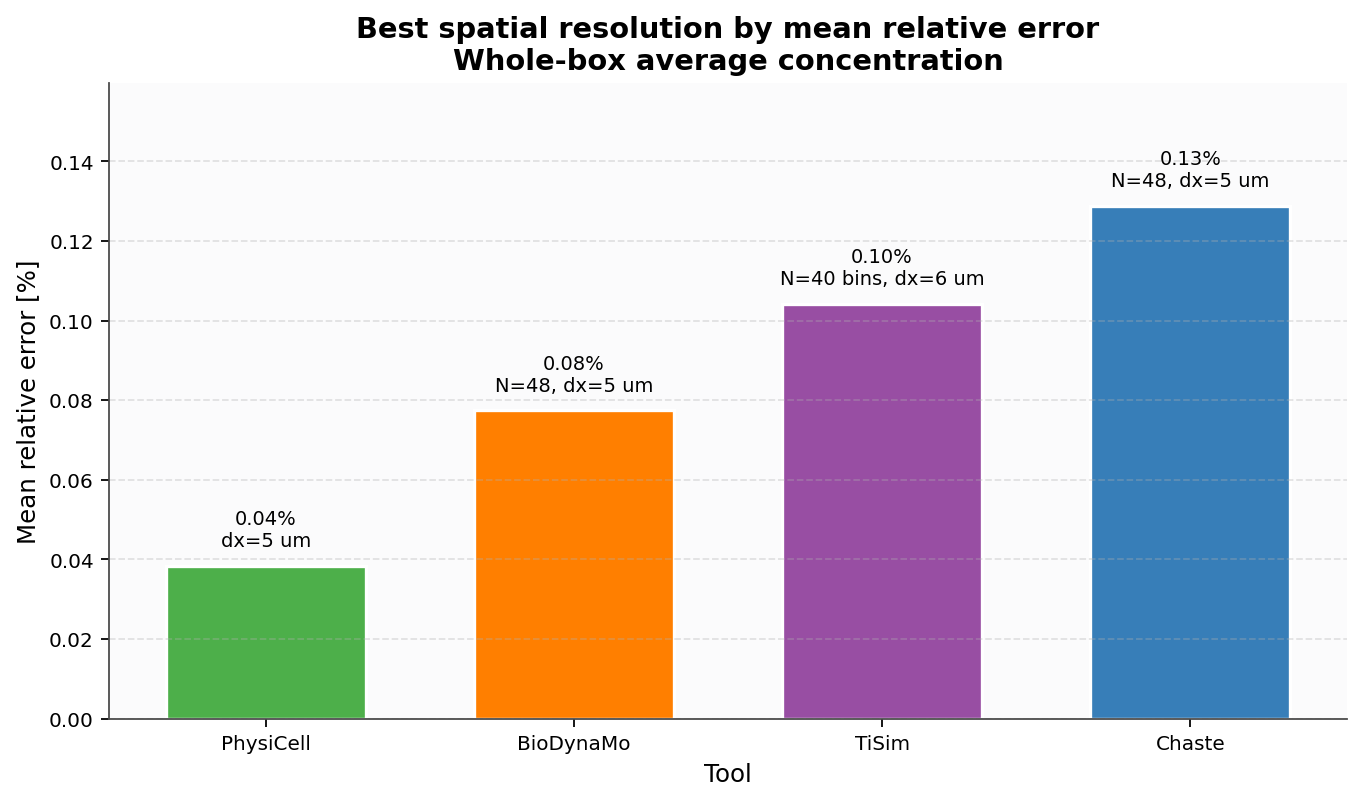

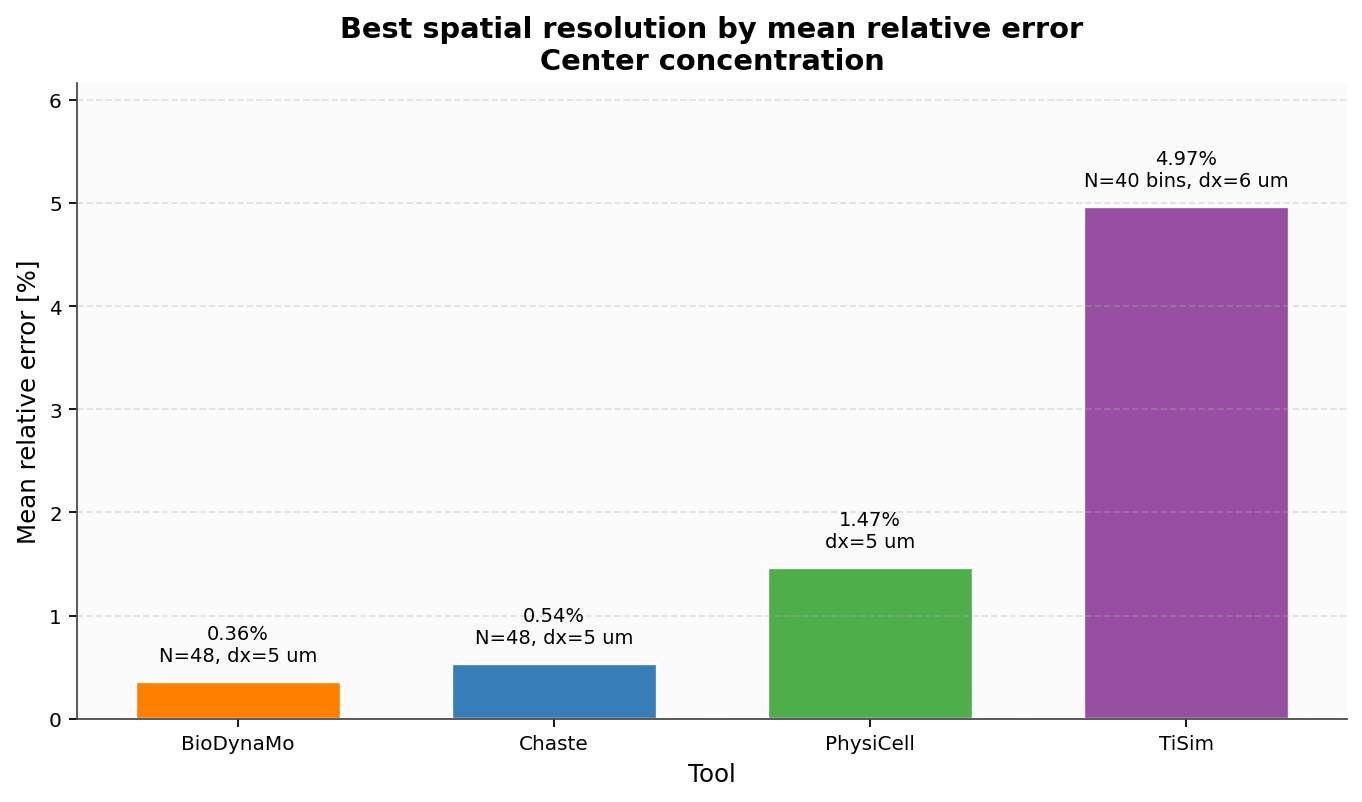

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/SuppMat/SuppMatPlots/diffusion_uptake_comparison


In [8]:
for metric_name in ['average', 'center']:
    metric_best = relative_best_runs[relative_best_runs['metric'] == metric_name].sort_values('mean_relative_error_percent').reset_index(drop=True)

    fig, axis = plt.subplots(figsize=(8.4, 4.9), constrained_layout=True)
    bars = axis.bar(
        metric_best['tool'],
        metric_best['mean_relative_error_percent'],
        width=0.65,
        color=[tool_colors[tool_name] for tool_name in metric_best['tool']],
        edgecolor='white',
        linewidth=1.5,
    )

    for bar, (_, row) in zip(bars, metric_best.iterrows()):
        if row['tool'] == 'CompuTiX':
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.2f} um\ndt={row['dt_min']:.1e} min"
        elif row['tool'] in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.0f} um"
        elif row['tool'] == 'TiSim':
            resolution_text = f"N={int(round(240 / row['dx_um']))} bins, dx={row['dx_um']:.0f} um"
        else:
            resolution_text = f"dx={row['dx_um']:.0f} um"

        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 0.03 * metric_best['mean_relative_error_percent'].max(),
            f"{row['mean_relative_error_percent']:.2f}%\n{resolution_text}",
            ha='center',
            va='bottom',
            fontsize=8.8,
        )

    axis.set_ylabel('Mean relative error [%]')
    axis.set_xlabel('Tool')
    axis.set_title(f'Best spatial resolution by mean relative error\n{metric_titles[metric_name]}')
    axis.set_ylim(0, metric_best['mean_relative_error_percent'].max() * 1.24)
    style_axis(axis)

    save_and_show(fig, f'best_relative_resolution_{metric_file_tokens[metric_name]}_uptake.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 6: Plot The Relative Error Over Time For Only The Best Runs

This is the first final comparison: one relative-error curve per tool for the best run selected under the whole-box average metric, and one relative-error curve per tool for the best run selected under the center metric.

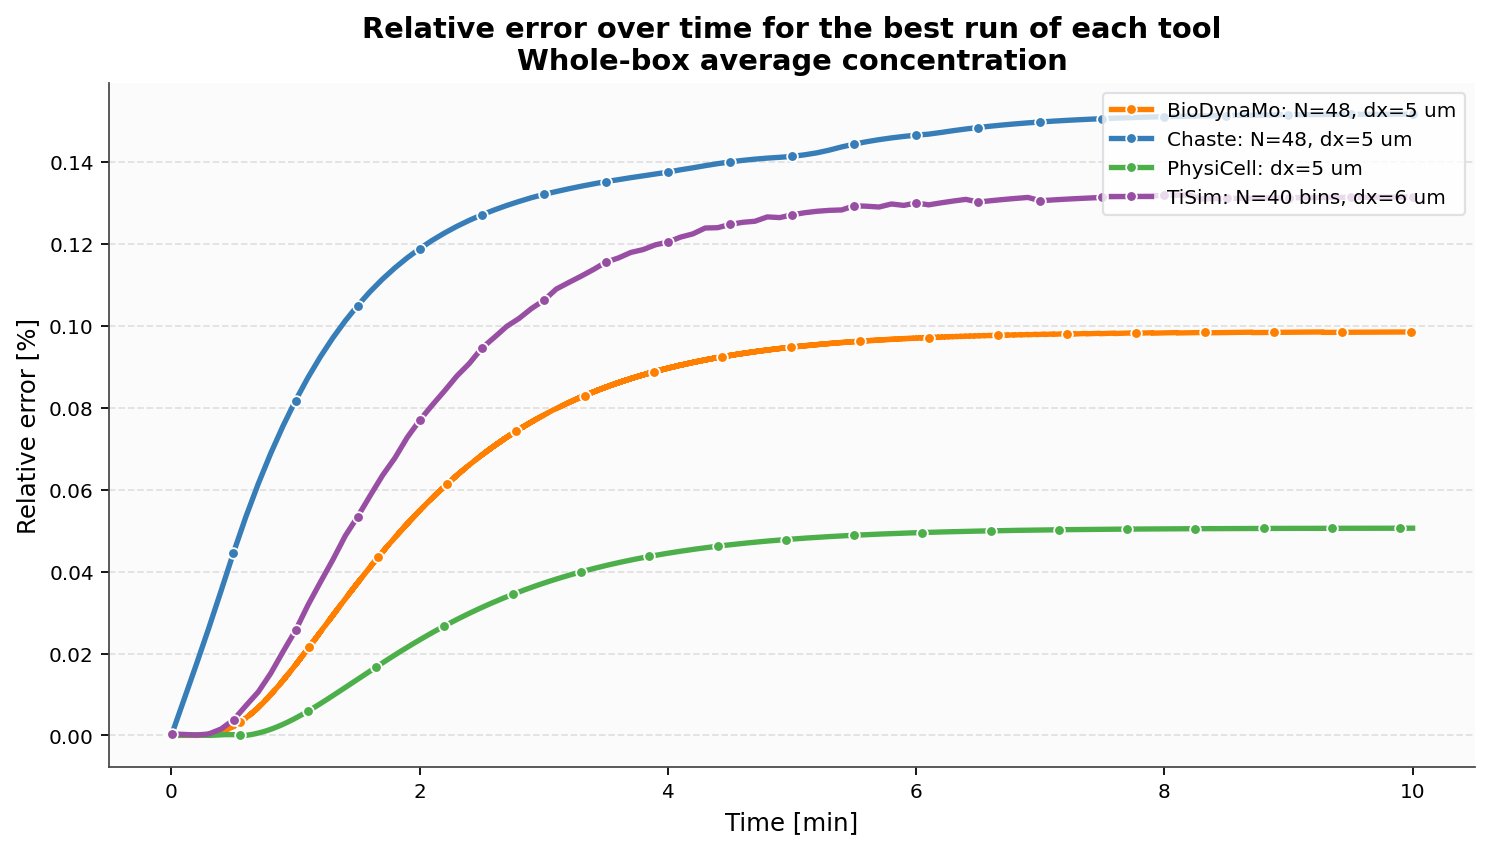

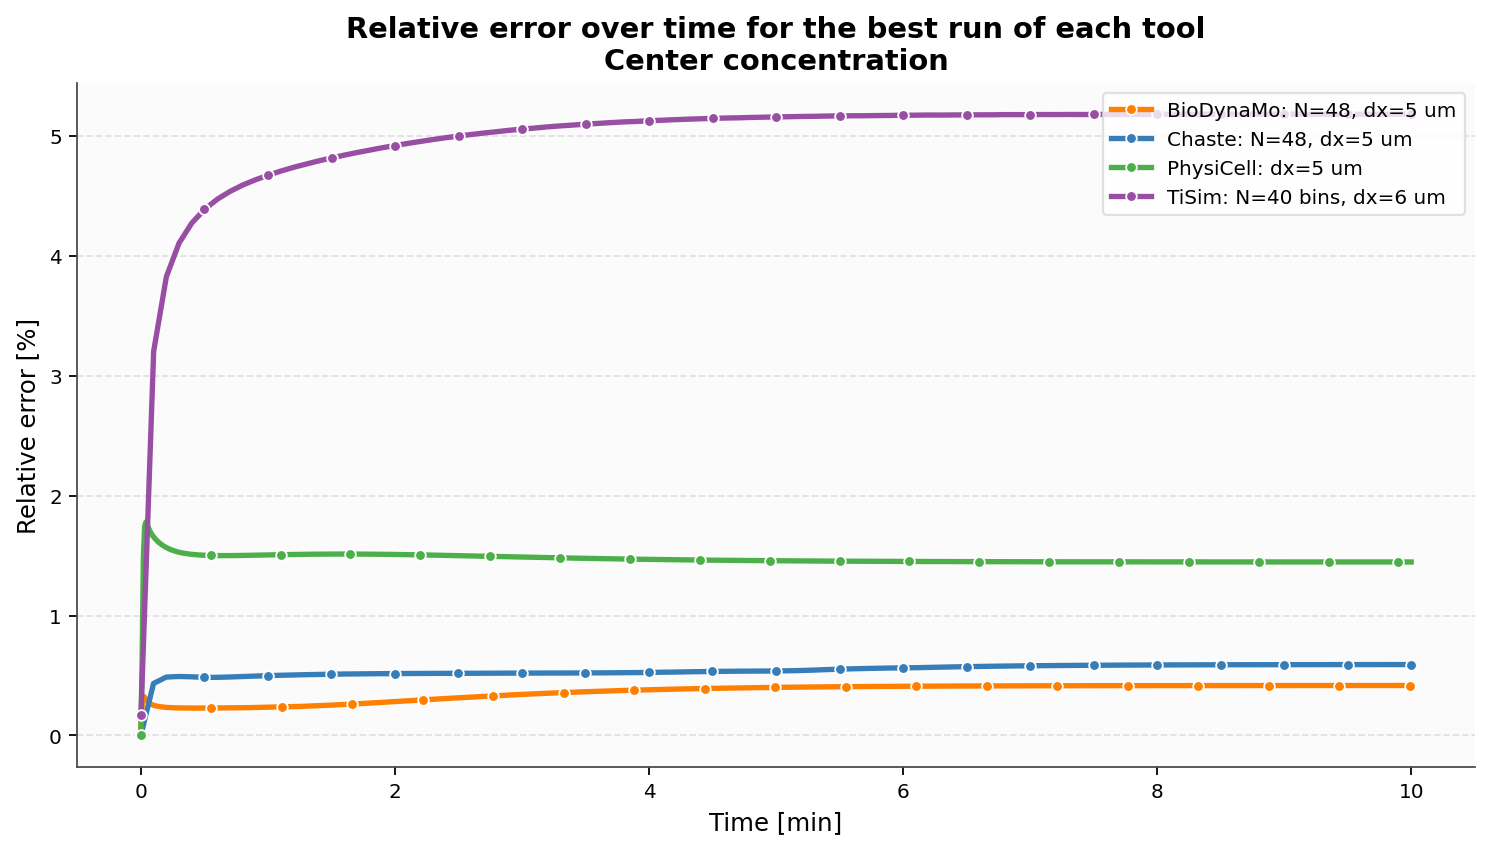

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/SuppMat/SuppMatPlots/diffusion_uptake_comparison


In [9]:
for metric_name in ['average', 'center']:
    metric_best_runs = relative_best_runs[relative_best_runs['metric'] == metric_name][['tool', 'run_id']]
    metric_comparison = comparison[comparison['metric'] == metric_name].merge(
        metric_best_runs,
        on=['tool', 'run_id'],
        how='inner',
        validate='many_to_one',
    )

    fig, axis = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)

    for tool_name, group in metric_comparison.groupby('tool'):
        group = group.sort_values('time_min').reset_index(drop=True)
        marker_step = max(len(group) // 18, 1)

        if tool_name == 'CompuTiX':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.2f} um, dt={group['dt_min'].iloc[0]:.1e} min"
        elif tool_name in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.0f} um"
        elif tool_name == 'TiSim':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))} bins, dx={group['dx_um'].iloc[0]:.0f} um"
        else:
            resolution_text = f"dx={group['dx_um'].iloc[0]:.0f} um"

        axis.plot(
            group['time_min'],
            group['relative_error_percent'],
            color=tool_colors[tool_name],
            linewidth=2.4,
            marker='o',
            markersize=4.8,
            markeredgecolor='white',
            markeredgewidth=0.8,
            markevery=marker_step,
            label=f"{tool_name}: {resolution_text}",
        )

    axis.set_xlabel('Time [min]')
    axis.set_ylabel('Relative error [%]')
    axis.set_title(f'Relative error over time for the best run of each tool\n{metric_titles[metric_name]}')
    style_axis(axis)
    axis.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d9d9df')

    save_and_show(fig, f'relative_error_over_time_{metric_file_tokens[metric_name]}_uptake.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 7: Keep Only The Best Resolution Per Tool And Per Metric Using Absolute Error

Now we repeat the same selection step using mean absolute error instead of mean relative error.

This identifies the best run for each tool under the whole-box average metric and under the center metric when the comparison is measured in uM.

In [10]:
# Select the best run per tool using the whole-box average metric only, then reuse that
# same run_id to report the corresponding center-metric results.
best_run_ids_by_absolute_error = (
    absolute_run_metrics[absolute_run_metrics['metric'] == 'average']
    .sort_values(['tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
    .groupby('tool', as_index=False)
    .first()[['tool', 'run_id']]
)

absolute_best_runs = (
    absolute_run_metrics.merge(best_run_ids_by_absolute_error, on=['tool', 'run_id'], how='inner')
    .sort_values(['metric', 'mean_absolute_error_uM'])
)

absolute_best_runs

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_absolute_error_uM,max_absolute_error_uM,rmse_uM
2,average,PhysiCell,PhysiCell_dx_5um_uptake,5.0,NaN,voxel size=5 um,1001,0.003748,0.004948,0.004100
0,average,BioDynaMo,BioDynaMo_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",10000,0.007583,0.009632,0.008165
3,average,TiSim,TiSim_N_40,6.0,NaN,"N=40 bins, dx=6 um",101,0.010196,0.012904,0.010960
1,average,Chaste,Chaste_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",101,0.012616,0.014832,0.013048
4,center,BioDynaMo,BioDynaMo_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",10000,0.026179,0.031553,0.026533
5,center,Chaste,Chaste_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",101,0.039113,0.042151,0.039357
6,center,PhysiCell,PhysiCell_dx_5um_uptake,5.0,NaN,voxel size=5 um,1001,0.106769,0.168887,0.107087
7,center,TiSim,TiSim_N_40,6.0,NaN,"N=40 bins, dx=6 um",101,0.359449,0.369268,0.361256


## Step 8: Plot The Absolute Error For The Best Run Of Each Tool

This is the second final comparison: one absolute-error curve per tool for the best run selected under the whole-box average metric, and one absolute-error curve per tool for the center metric.

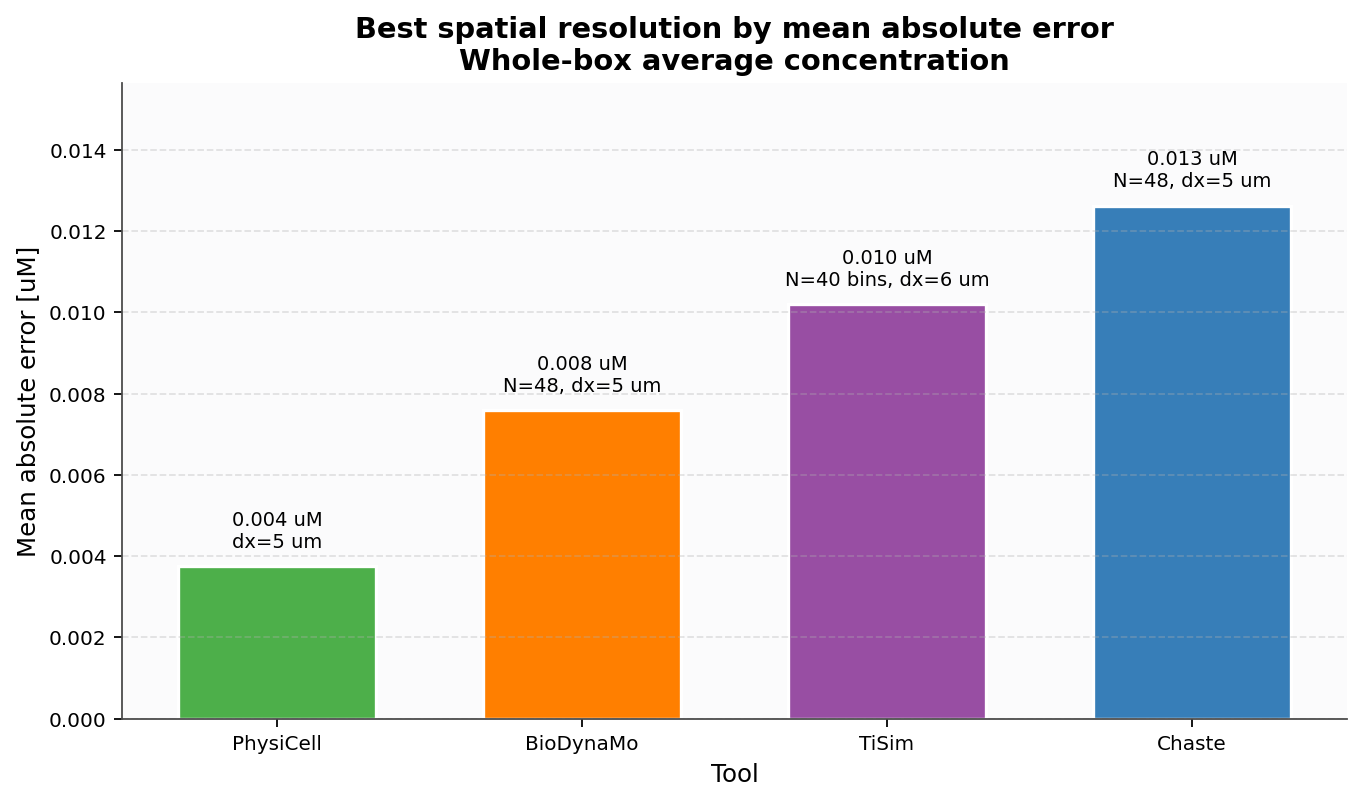

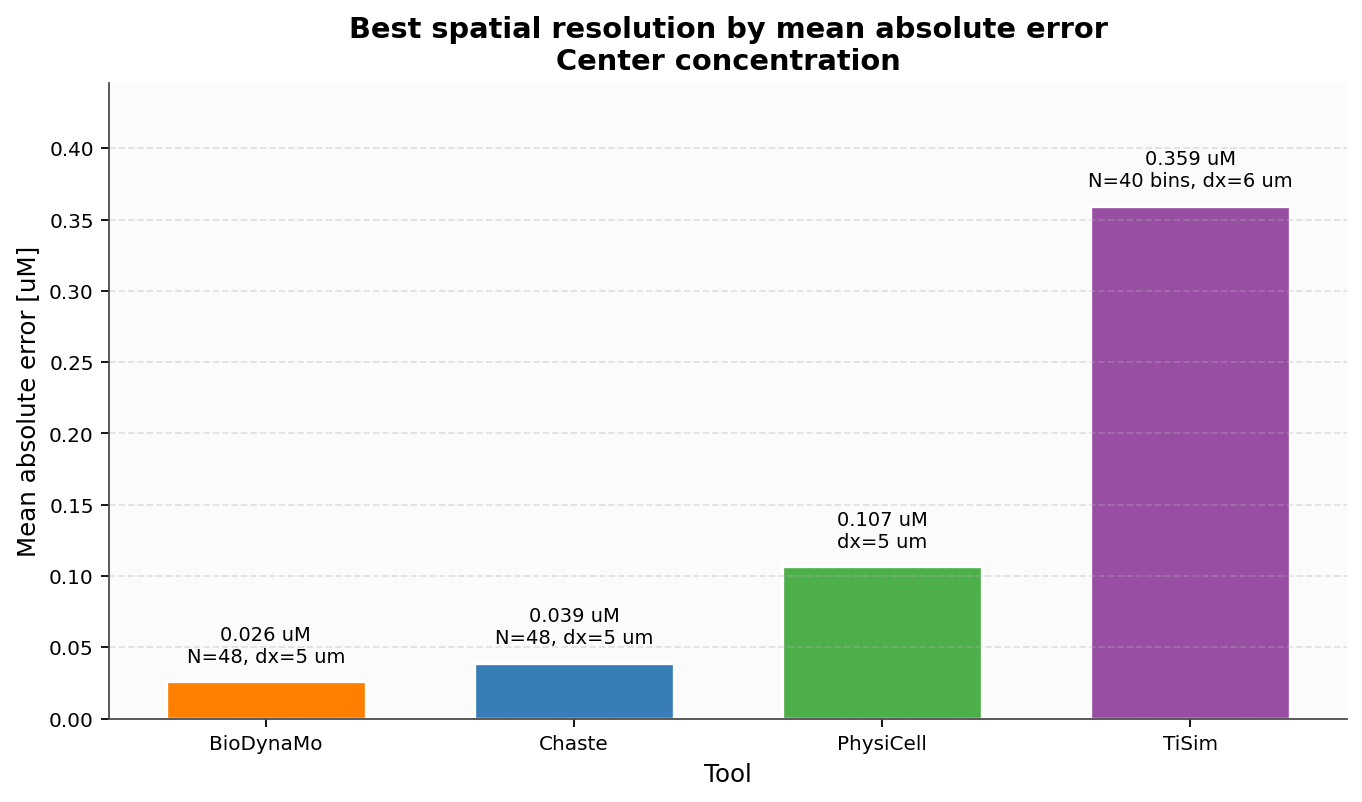

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/SuppMat/SuppMatPlots/diffusion_uptake_comparison


In [11]:
for metric_name in ['average', 'center']:
    metric_best = absolute_best_runs[absolute_best_runs['metric'] == metric_name].sort_values('mean_absolute_error_uM').reset_index(drop=True)

    fig, axis = plt.subplots(figsize=(8.4, 4.9), constrained_layout=True)
    bars = axis.bar(
        metric_best['tool'],
        metric_best['mean_absolute_error_uM'],
        width=0.65,
        color=[tool_colors[tool_name] for tool_name in metric_best['tool']],
        edgecolor='white',
        linewidth=1.5,
    )

    for bar, (_, row) in zip(bars, metric_best.iterrows()):
        if row['tool'] == 'CompuTiX':
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.2f} um\ndt={row['dt_min']:.1e} min"
        elif row['tool'] in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.0f} um"
        elif row['tool'] == 'TiSim':
            resolution_text = f"N={int(round(240 / row['dx_um']))} bins, dx={row['dx_um']:.0f} um"
        else:
            resolution_text = f"dx={row['dx_um']:.0f} um"

        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 0.03 * metric_best['mean_absolute_error_uM'].max(),
            f"{row['mean_absolute_error_uM']:.3f} uM\n{resolution_text}",
            ha='center',
            va='bottom',
            fontsize=8.8,
        )

    axis.set_ylabel('Mean absolute error [uM]')
    axis.set_xlabel('Tool')
    axis.set_title(f'Best spatial resolution by mean absolute error\n{metric_titles[metric_name]}')
    axis.set_ylim(0, metric_best['mean_absolute_error_uM'].max() * 1.24)
    style_axis(axis)

    save_and_show(fig, f'best_absolute_resolution_{metric_file_tokens[metric_name]}_uptake.png')

print(f'Saved standalone plots to {plot_output_dir}')

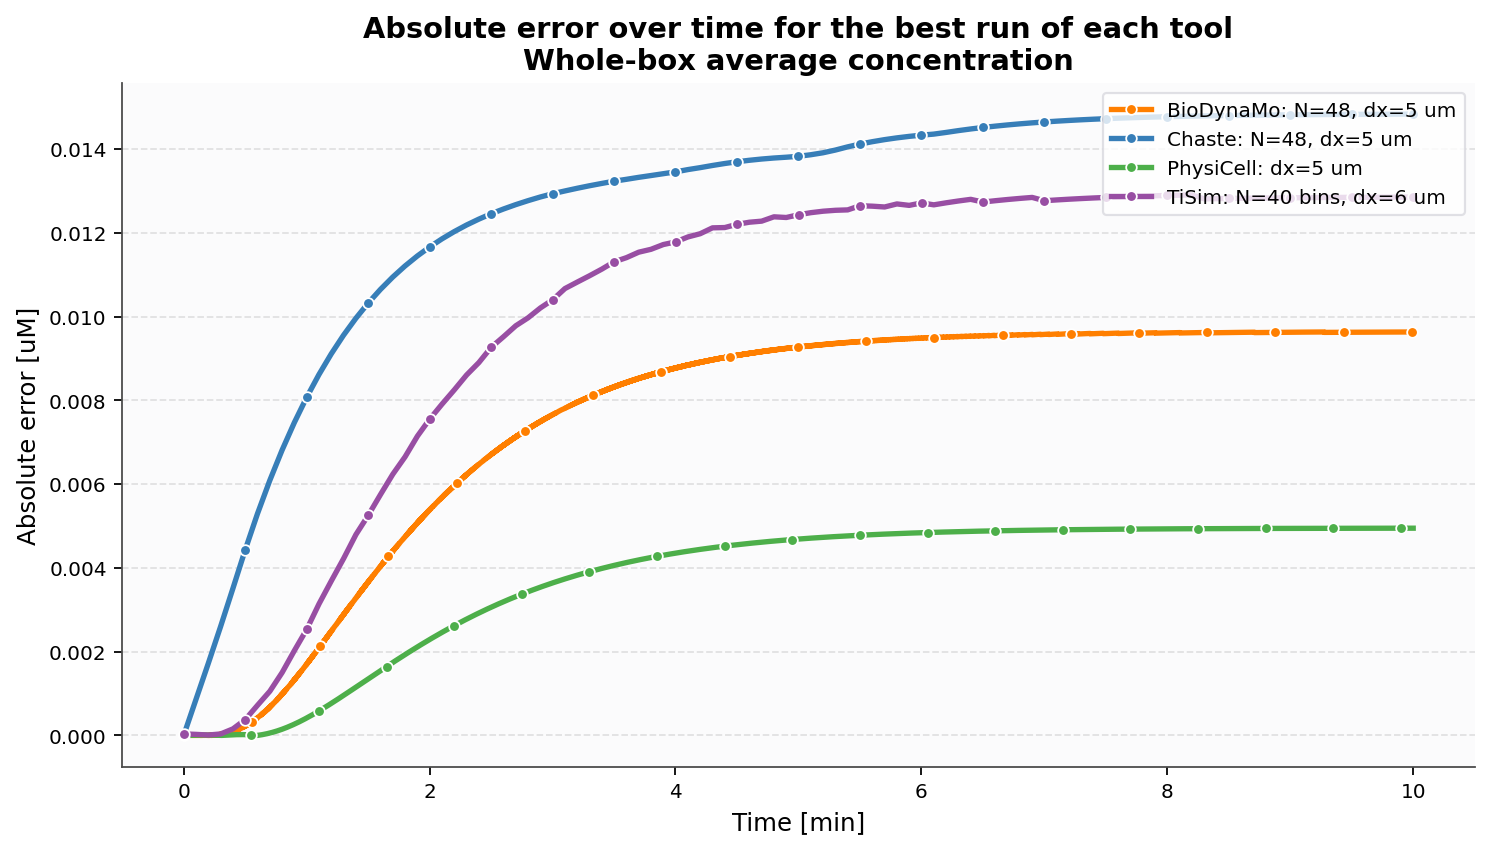

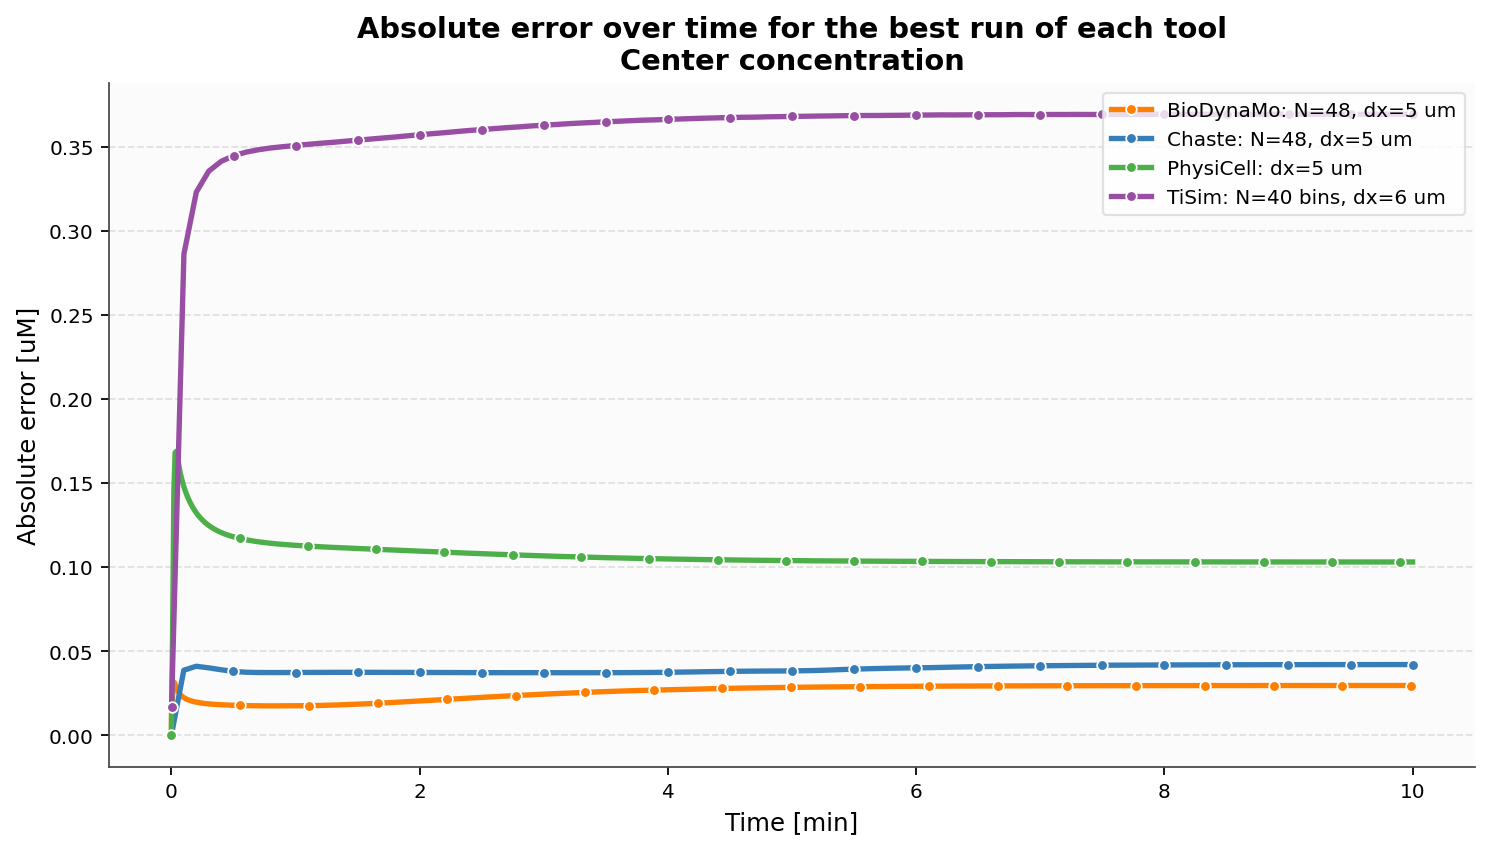

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/SuppMat/SuppMatPlots/diffusion_uptake_comparison


In [12]:
for metric_name in ['average', 'center']:
    metric_best_runs = absolute_best_runs[absolute_best_runs['metric'] == metric_name][['tool', 'run_id']]
    metric_comparison = comparison[comparison['metric'] == metric_name].merge(
        metric_best_runs,
        on=['tool', 'run_id'],
        how='inner',
        validate='many_to_one',
    )

    fig, axis = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)

    for tool_name, group in metric_comparison.groupby('tool'):
        group = group.sort_values('time_min').reset_index(drop=True)
        marker_step = max(len(group) // 18, 1)

        if tool_name == 'CompuTiX':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.2f} um, dt={group['dt_min'].iloc[0]:.1e} min"
        elif tool_name in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.0f} um"
        elif tool_name == 'TiSim':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))} bins, dx={group['dx_um'].iloc[0]:.0f} um"
        else:
            resolution_text = f"dx={group['dx_um'].iloc[0]:.0f} um"

        axis.plot(
            group['time_min'],
            group['absolute_error_uM'],
            color=tool_colors[tool_name],
            linewidth=2.4,
            marker='o',
            markersize=4.8,
            markeredgecolor='white',
            markeredgewidth=0.8,
            markevery=marker_step,
            label=f"{tool_name}: {resolution_text}",
        )

    axis.set_xlabel('Time [min]')
    axis.set_ylabel('Absolute error [uM]')
    axis.set_title(f'Absolute error over time for the best run of each tool\n{metric_titles[metric_name]}')
    style_axis(axis)
    axis.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d9d9df')

    save_and_show(fig, f'absolute_error_over_time_{metric_file_tokens[metric_name]}_uptake.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 9: Recompute Errors With Interpolated Analytical Values

This section keeps the original rounded-time matching workflow intact and adds a second comparison path where the analytical reference is interpolated directly onto each simulation time grid.

The goal is to compare the two alignment strategies side by side before deciding which one is the better basis for cross-tool benchmarking.

## Step 9: Exact-Time Comparison Summary

The primary uptake comparison above uses exact native timepoint matches. This section reports the matched coverage so missing analytical or simulation timepoints are visible instead of being rounded, interpolated, or silently duplicated.

In [13]:
matched_timepoint_summary = (
    comparison.groupby(['metric', 'tool', 'run_id'], as_index=False)
    .agg(
        matched_points=('time_min', 'size'),
        first_matched_time_min=('time_min', 'min'),
        last_matched_time_min=('time_min', 'max'),
    )
    .sort_values(['metric', 'tool', 'run_id'])
)

matched_timepoint_summary

,metric,tool,run_id,matched_points,first_matched_time_min,last_matched_time_min
0,average,BioDynaMo,BioDynaMo_N_12,1000,0.000,9.990
1,average,BioDynaMo,BioDynaMo_N_24,10000,0.000,9.999
2,average,BioDynaMo,BioDynaMo_N_48,10000,0.000,9.999
3,average,BioDynaMo,BioDynaMo_N_6,1000,0.000,9.990
4,average,Chaste,Chaste_N_12,101,0.000,10.000
5,average,Chaste,Chaste_N_24,101,0.000,10.000
6,average,Chaste,Chaste_N_48,101,0.000,10.000
7,average,Chaste,Chaste_N_6,101,0.000,10.000
8,average,PhysiCell,PhysiCell_dx_10um_uptake,1001,0.000,10.000
9,average,PhysiCell,PhysiCell_dx_20um_uptake,1001,0.000,10.000


## Step 10: Plot Concentration For The Selected Runs

The uptake notebook previously plotted only relative and absolute errors. These concentration plots fill that gap by showing both observed metrics and the analytical reference for the same runs selected by whole-box average absolute error.

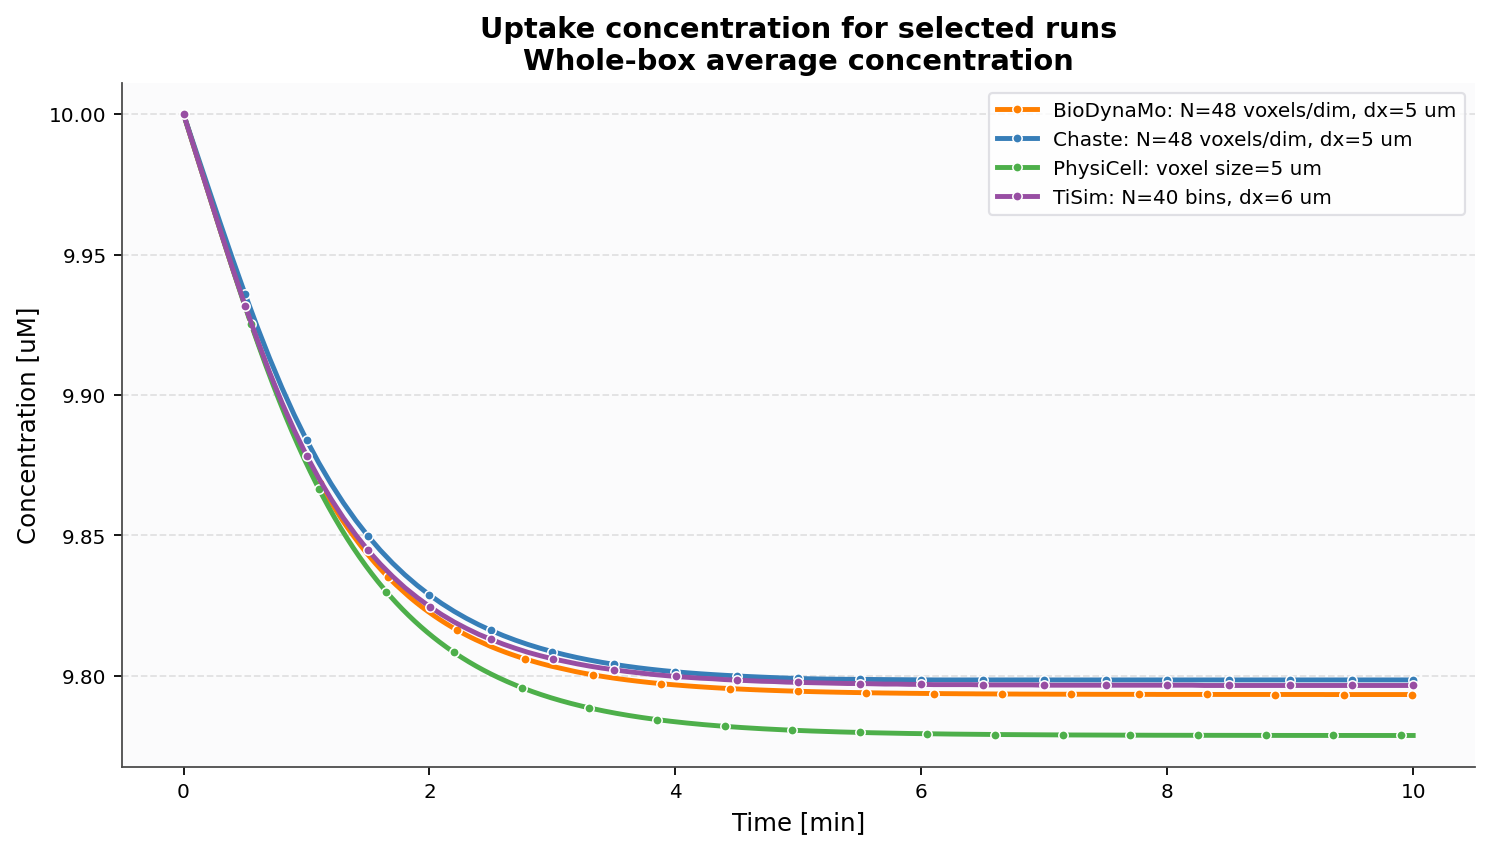

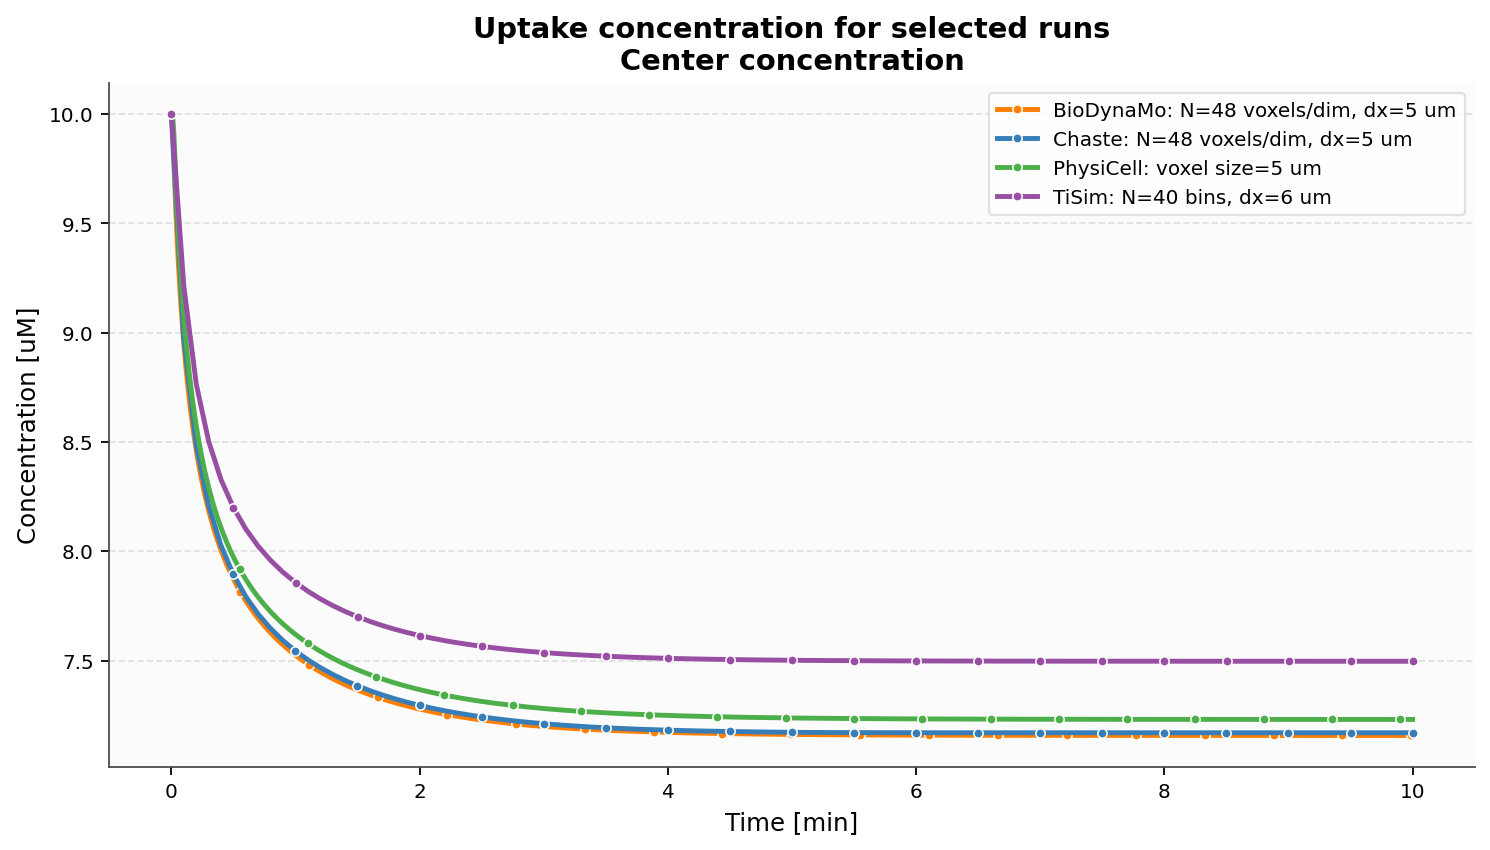

Saved concentration plots to /home/tntiniak/Work/observatory_benchmark/SuppMat/SuppMatPlots/diffusion_uptake_comparison


In [14]:
best_average_run_ids = absolute_best_runs.loc[
    absolute_best_runs['metric'] == 'average',
    ['tool', 'run_id'],
].drop_duplicates()

# Plot the full native simulation traces. Exact matching is used only for error metrics.
best_concentration_runs = all_runs.merge(
    best_average_run_ids,
    on=['tool', 'run_id'],
    how='inner',
    validate='many_to_one',
)

for metric_name, observed_column, analytical_column in [
    ('average', 'average_uM', 'analytical_average_uM'),
    ('center', 'center_uM', 'analytical_center_uM'),
]:
    figure, axis = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)

    for tool_name, group in best_concentration_runs.groupby('tool'):
        group = group.sort_values('time_min')
        axis.plot(
            group['time_min'],
            group[observed_column],
            color=tool_colors[tool_name],
            linewidth=2.2,
            marker='o',
            markersize=4.2,
            markeredgecolor='white',
            markeredgewidth=0.7,
            markevery=max(len(group) // 18, 1),
            label=f"{tool_name}: {group['resolution_label'].iloc[0]}",
        )

    # reference = analytical_reference.sort_values('time_min')
    # axis.plot(
    #     reference['time_min'],
    #     reference[analytical_column],
    #     color='black',
    #     linestyle='--',
    #     linewidth=2.0,
    #     label='Analytical',
    # )
    axis.set_xlabel('Time [min]')
    axis.set_ylabel('Concentration [uM]')
    axis.set_title(f'Uptake concentration for selected runs\n{metric_titles[metric_name]}')
    style_axis(axis)
    axis.legend(loc='best', frameon=True, facecolor='white', edgecolor='#d9d9df')

    save_and_show(figure, f'concentration_over_time_{metric_file_tokens[metric_name]}_uptake.png')

print(f'Saved concentration plots to {plot_output_dir}')

## Step 11: Nature-Style Concentration And Relative Error

The top panel shows the whole-box average concentration for each tool's average-error-selected run against the analytical reference. The lower panel shows relative error for those same selected runs at exact matched timestamps.

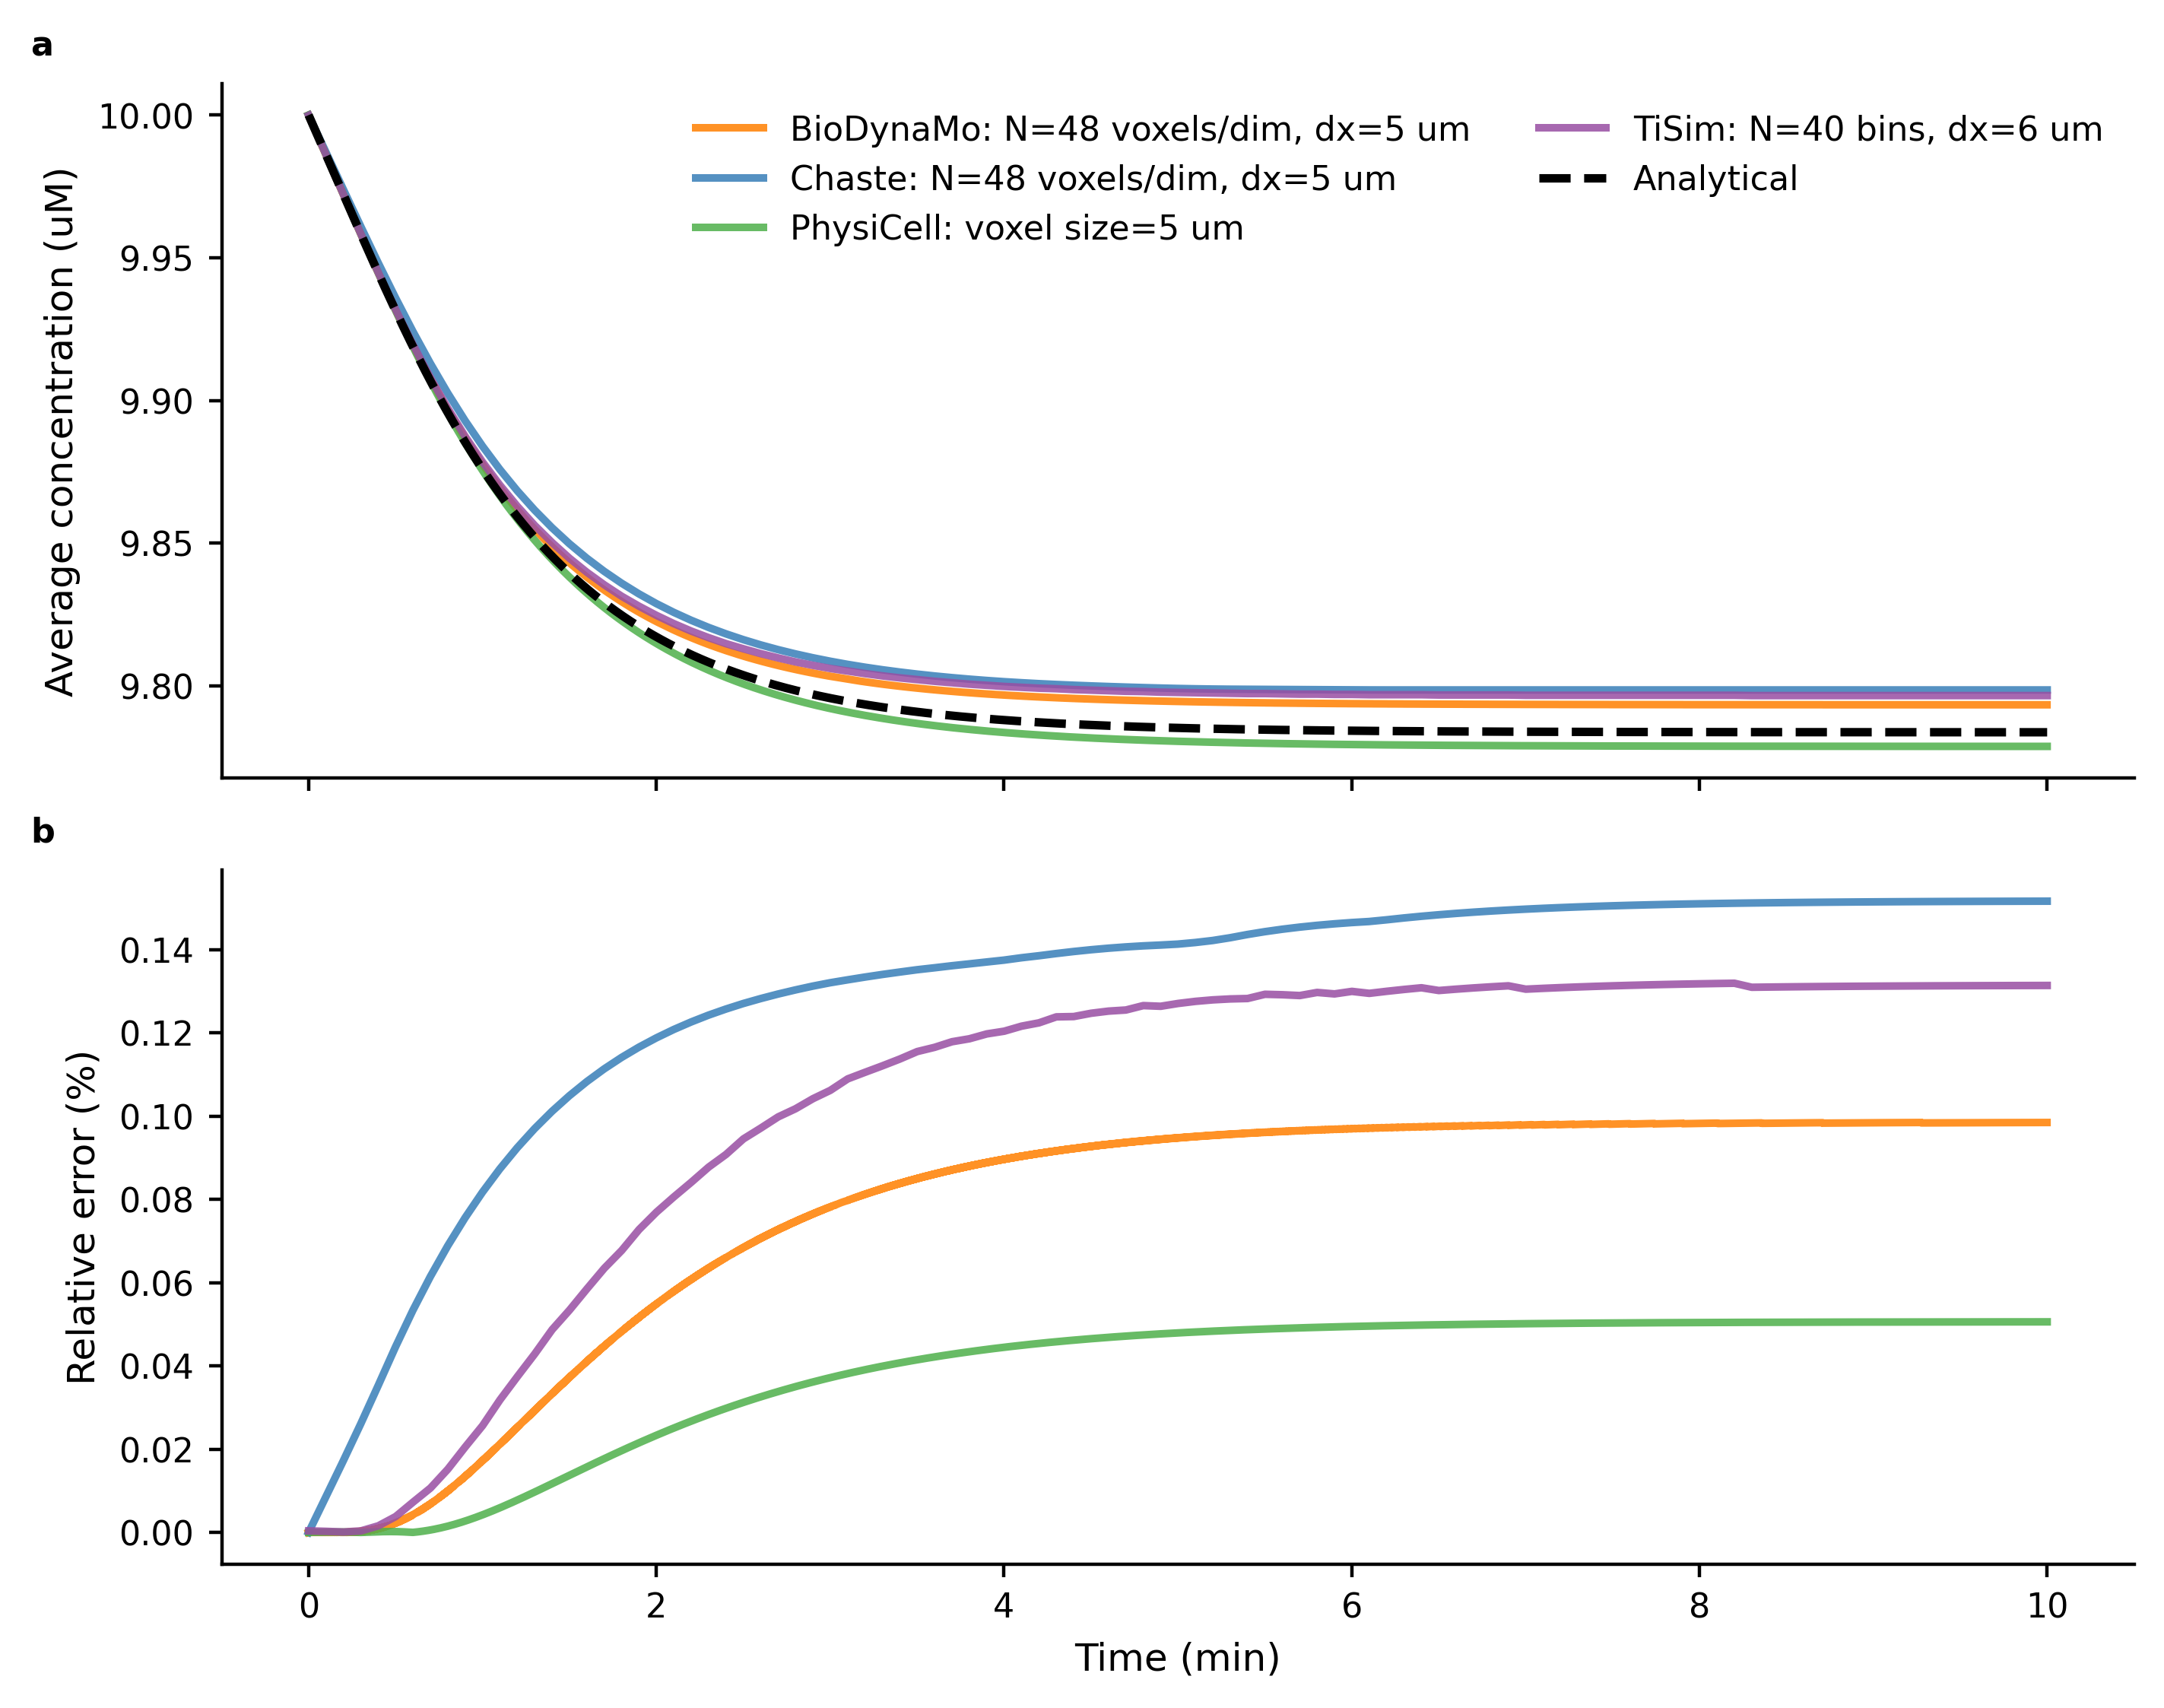

Saved Nature-style plot to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/plots/diffusion_uptake


In [15]:
nature_plot_dir = ROOT / 'ResultAnalysis' / 'plots' / 'diffusion_uptake'
nature_plot_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial', 'sans-serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'figure.dpi': 400,
})

best_average_run_ids = absolute_best_runs.loc[
    absolute_best_runs['metric'] == 'average',
    ['tool', 'run_id'],
].drop_duplicates()

best_average_error_comparison = comparison.loc[
    comparison['metric'] == 'average'
].merge(
    best_average_run_ids,
    on=['tool', 'run_id'],
    how='inner',
    validate='many_to_one',
)

analytical_average = analytical_df.sort_values('time_min')
fig, (ax_concentration, ax_error) = plt.subplots(
    2, 1, figsize=(7, 5.5), sharex=True, constrained_layout=True,
)

for tool_name, group in best_concentration_runs.groupby('tool'):
    group = group.sort_values('time_min')
    ax_concentration.plot(
        group['time_min'],
        group['average_uM'],
        color=tool_colors[tool_name],
        linewidth=1.8,
        alpha=0.85,
        label=f"{tool_name}: {group['resolution_label'].iloc[0]}",
    )

ax_concentration.plot(
    analytical_average['time_min'],
    analytical_average['average_concentration_uM'],
    color='black',
    linestyle='--',
    linewidth=2.0,
    label='Analytical',
)

for tool_name, group in best_average_error_comparison.groupby('tool'):
    group = group.sort_values('time_min')
    ax_error.plot(
        group['time_min'],
        group['relative_error_percent'],
        color=tool_colors[tool_name],
        linewidth=1.8,
        alpha=0.85,
    )

ax_concentration.set_ylabel('Average concentration (uM)')
ax_error.set_ylabel('Relative error (%)')
ax_error.set_xlabel('Time (min)')

for panel_label, axis in zip(['a', 'b'], [ax_concentration, ax_error]):
    axis.text(-0.1, 1.04, panel_label, transform=axis.transAxes, fontweight='bold')
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.tick_params(direction='out', width=0.8, length=3)

ax_concentration.legend(loc='best', ncol=2, frameon=False)
fig.savefig(nature_plot_dir / 'uptake_nature_style_combined.svg', bbox_inches='tight')
fig.savefig(nature_plot_dir / 'uptake_nature_style_combined.png', bbox_inches='tight', dpi=600)
plt.show()
plt.close(fig)

print(f'Saved Nature-style plot to {nature_plot_dir}')